#  Heart Failure Risk Prediction
## Exploratory Data Analysis (EDA)

>   Coding Week — Centrale Casablanca   
> Dataset: [UCI Heart Failure Clinical Records](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records)

---

###  Objectifs de ce notebook
1. Charger et explorer le dataset
2. Analyser les valeurs manquantes
3. Détecter et traiter les outliers
4. Analyser le déséquilibre des classes
5. Analyser les corrélations entre features
6. Visualisations complètes

##  1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print(' Libraries imported successfully')

 Libraries imported successfully


##  2. Chargement du Dataset

In [29]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv")

print(f' Shape: {df.shape[0]} patients × {df.shape[1]} features')
df.head(10)

 Shape: 299 patients × 13 features


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


In [6]:
print('=== Types de données ===')
print(df.info())
print()
print('=== Statistiques descriptives ===')
df.describe().round(2)

=== Types de données ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 3

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00
mean,60.83,0.43,581.84,0.42,38.08,0.35,263358.03,1.39,136.63,0.65,0.32,130.26,0.32
std,11.89,0.50,970.29,0.49,11.83,0.48,97804.24,1.03,4.41,0.48,0.47,77.61,0.47
min,40.00,0.00,23.00,0.00,14.00,0.00,25100.00,0.50,113.00,0.00,0.00,4.00,0.00
25%,51.00,0.00,116.50,0.00,30.00,0.00,212500.00,0.90,134.00,0.00,0.00,73.00,0.00
50%,60.00,0.00,250.00,0.00,38.00,0.00,262000.00,1.10,137.00,1.00,0.00,115.00,0.00
75%,70.00,1.00,582.00,1.00,45.00,1.00,303500.00,1.40,140.00,1.00,1.00,203.00,1.00
max,95.00,1.00,7861.00,1.00,80.00,1.00,850000.00,9.40,148.00,1.00,1.00,285.00,1.00


##  3. Analyse des Valeurs Manquantes

In [14]:
missing = df.isnull().sum()

if missing.sum() == 0:
    print(' AUCUNE valeur manquante détectée !')
    print(' Aucun traitement nécessaire pour les valeurs manquantes.')
else:
    # Trouver les indices exacts (ligne, colonne)
    positions = np.argwhere(df.isnull().values)
    print(f' {missing.sum()} valeurs manquantes détectées :')
    print()
    for row, col in positions:
        print(f'   → Ligne {row} | Colonne : {df.columns[col]}')

 AUCUNE valeur manquante détectée !
 Aucun traitement nécessaire pour les valeurs manquantes.


##  4. Détection et Traitement des Outliers

In [12]:
# Détection simple des outliers
numeric_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                'platelets', 'serum_creatinine', 'serum_sodium', 'time']

for col in numeric_cols:
    mean = df[col].mean()
    std  = df[col].std()
    n_out = df[(df[col] < mean - 3*std) | (df[col] > mean + 3*std)].shape[0]
    print(f'{col:35s} → {n_out} outliers')

age                                 → 0 outliers
creatinine_phosphokinase            → 7 outliers
ejection_fraction                   → 1 outliers
platelets                           → 3 outliers
serum_creatinine                    → 6 outliers
serum_sodium                        → 3 outliers
time                                → 0 outliers


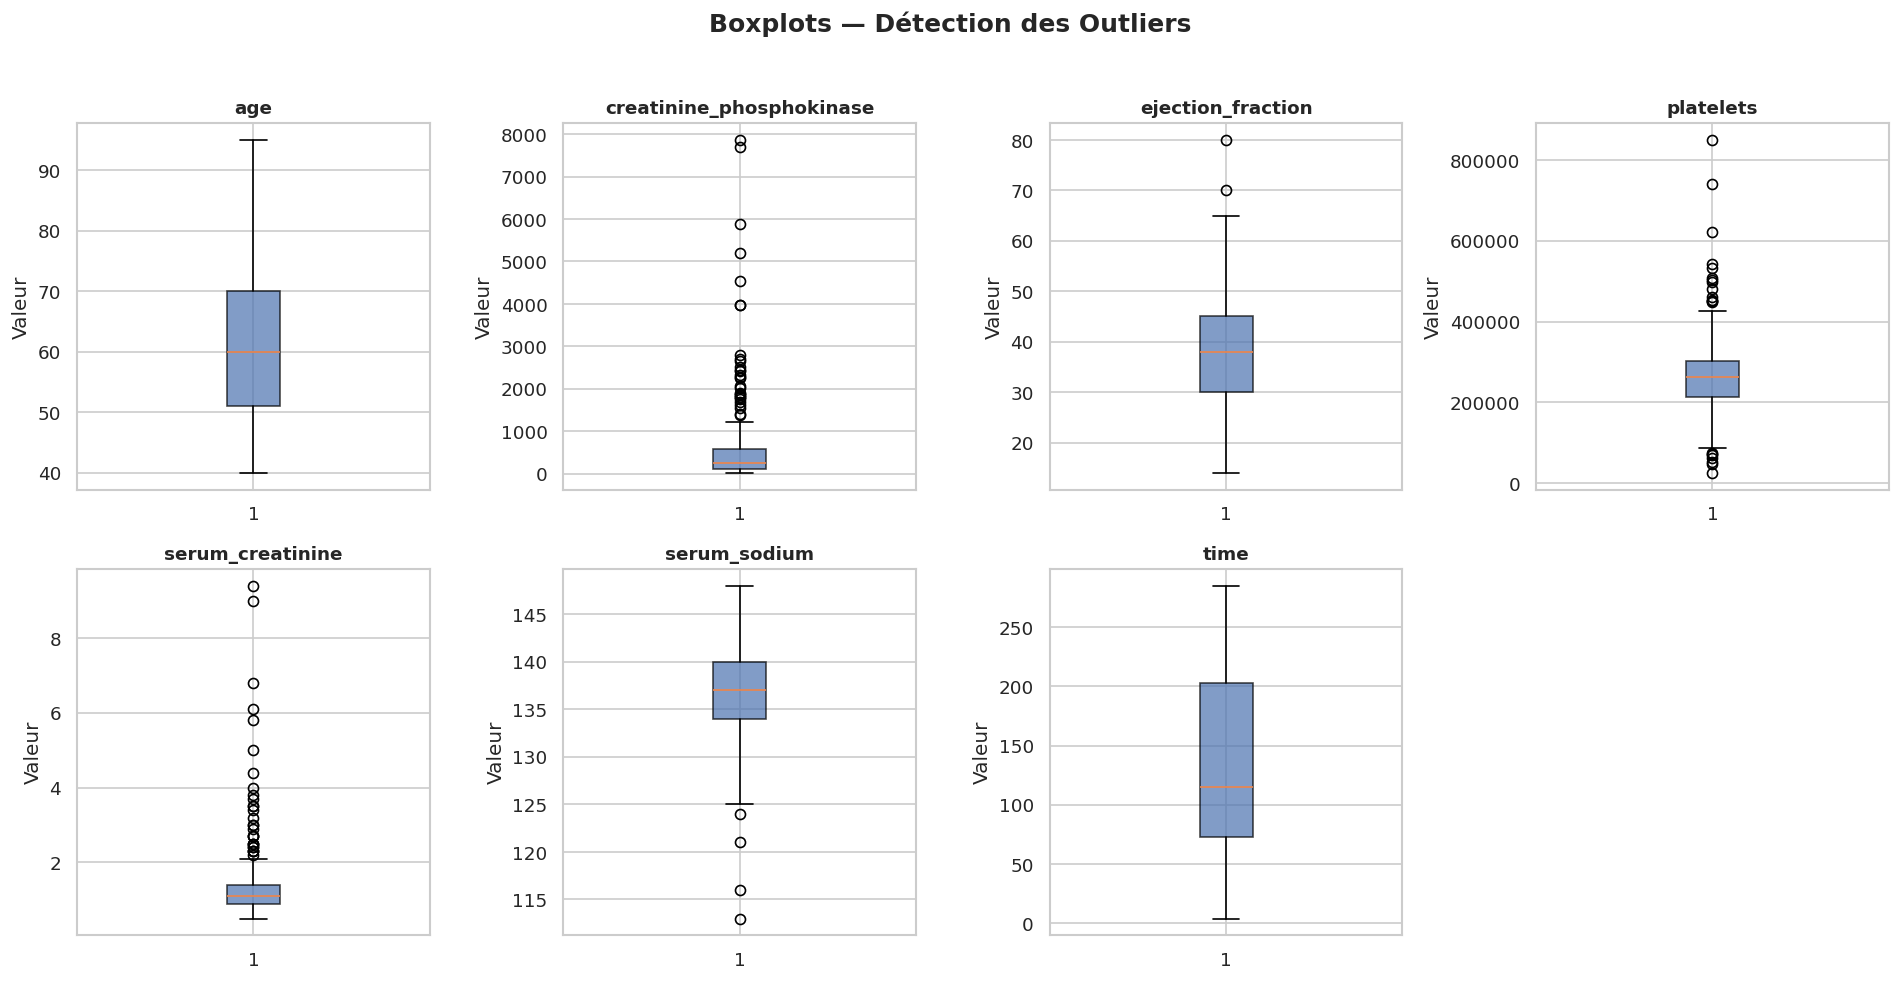

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valeur')

axes[-1].axis('off')
fig.suptitle('Boxplots — Détection des Outliers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##  Décision sur les Outliers

Les colonnes creatinine_phosphokinase et serum_creatinine contiennent
le plus grand nombre d'outliers (7-6 chacune).

Cependant, ces données sont médicales — ces valeurs extrêmes
représentent de vrais patients gravement malades.

Les supprimer ferait perdre des informations critiques sur les
cas les plus sévères, ce qui biaiserait le modèle.

    Décision : on garde toutes les valeurs sans modification.

##  5. Déséquilibre des Classes (Class Imbalance)
Le dataset contient 299 patients, mais les classes ne sont pas
réparties de manière égale. En effet, approximately 68% des patients
ont survécu (203 patients) contre seulement 32% de décès (96 patients).

Ce déséquilibre est problématique car un modèle entraîné sans
correction pourrait prédire systématiquement "Survécu" et atteindre
68% d'accuracy sans réellement apprendre les cas de décès — ce qui
est inacceptable dans un contexte médical.

Pour corriger ce déséquilibre, nous avons choisi d'appliquer SMOTE
(Synthetic Minority Oversampling Technique) uniquement sur le train set.
Cette méthode génère des patients synthétiques de la classe minoritaire
(décédés) en interpolant entre les cas existants, sans perte
d'information contrairement à l'undersampling.

In [21]:
class_counts = df['DEATH_EVENT'].value_counts()
class_pct = df['DEATH_EVENT'].value_counts(normalize=True) * 100

print('=== Distribution des Classes ===')
print(f"Survécu  (0) : {class_counts[0]} patients ({class_pct[0]:.1f}%)")
print(f"Décédé   (1) : {class_counts[1]} patients ({class_pct[1]:.1f}%)")
print()
print('  Dataset DÉSÉQUILIBRÉ — ratio ~2:1')

=== Distribution des Classes ===
Survécu  (0) : 203 patients (67.9%)
Décédé   (1) : 96 patients (32.1%)

  Dataset DÉSÉQUILIBRÉ — ratio ~2:1


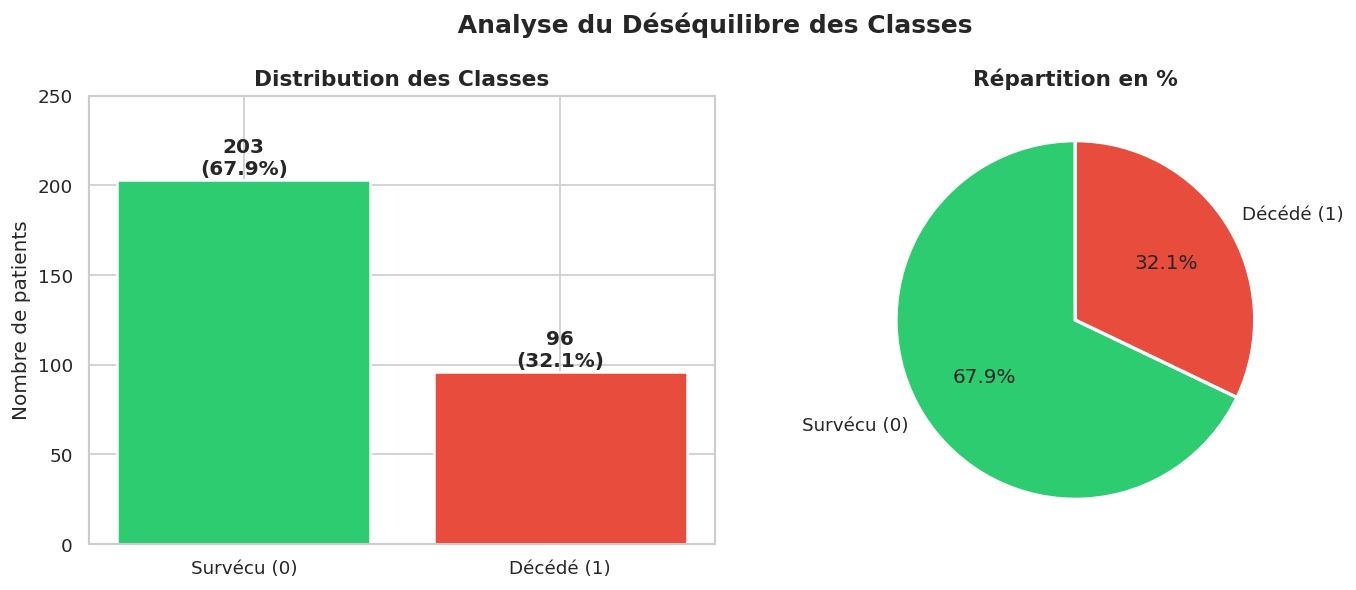

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Survécu (0)', 'Décédé (1)'], class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 3, f'{v}\n({class_pct.values[i]:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribution des Classes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_ylim(0, 250)

# Pie chart
axes[1].pie(class_counts.values, labels=['Survécu (0)', 'Décédé (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Répartition en %', fontsize=13, fontweight='bold')

fig.suptitle(' Analyse du Déséquilibre des Classes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['DEATH_EVENT'])
y = df_clean['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Avant SMOTE :')
print(y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Après SMOTE :')
print(pd.Series(y_train_res).value_counts().to_dict())
print()
print(' Classes parfaitement équilibrées après SMOTE')
print(' Justification : SMOTE génère des exemples synthétiques de la classe minoritaire')
print('   plutôt que de dupliquer, ce qui évite le surapprentissage.')

Avant SMOTE :
{0: 162, 1: 77}
Après SMOTE :
{0: 162, 1: 162}

 Classes parfaitement équilibrées après SMOTE
 Justification : SMOTE génère des exemples synthétiques de la classe minoritaire
   plutôt que de dupliquer, ce qui évite le surapprentissage.


##  6. Analyse des Corrélations

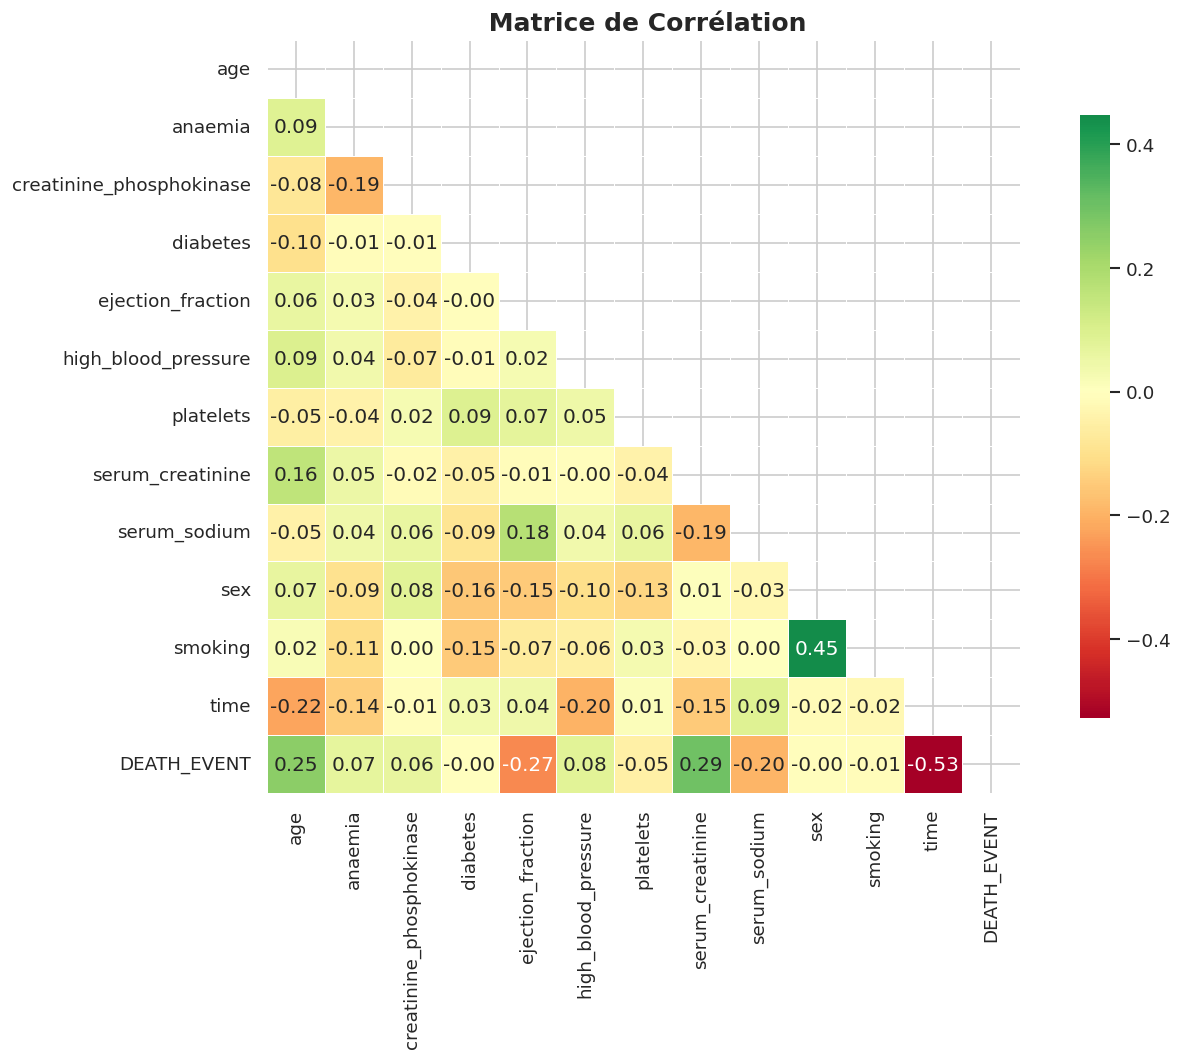

In [20]:
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title(' Matrice de Corrélation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

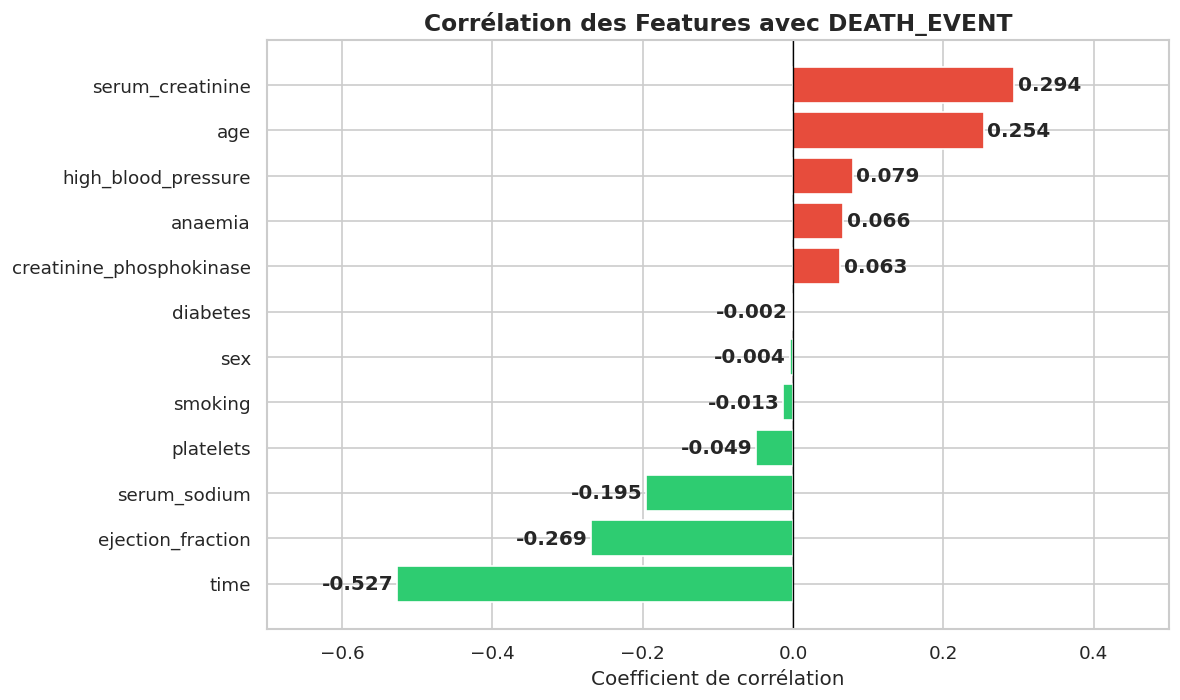

🔴 Features positivement corrélées (risque ↑) : serum_creatinine, age, high_blood_pressure
🟢 Features négativement corrélées (risque ↓) : time, ejection_fraction, serum_sodium
⚪ Features peu corrélées : diabetes, sex, smoking → à surveiller lors de la modélisation


In [28]:
corr_target = df.corr()['DEATH_EVENT'].drop('DEATH_EVENT').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-0.7, 0.5)  # ← agrandit l'échelle horizontale
ax.set_title('Corrélation des Features avec DEATH_EVENT', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient de corrélation')
plt.tight_layout()
plt.show()

print('🔴 Features positivement corrélées (risque ↑) : serum_creatinine, age, high_blood_pressure')
print('🟢 Features négativement corrélées (risque ↓) : time, ejection_fraction, serum_sodium')
print('⚪ Features peu corrélées : diabetes, sex, smoking → à surveiller lors de la modélisation')

##  8. Distributions des Features par Classe

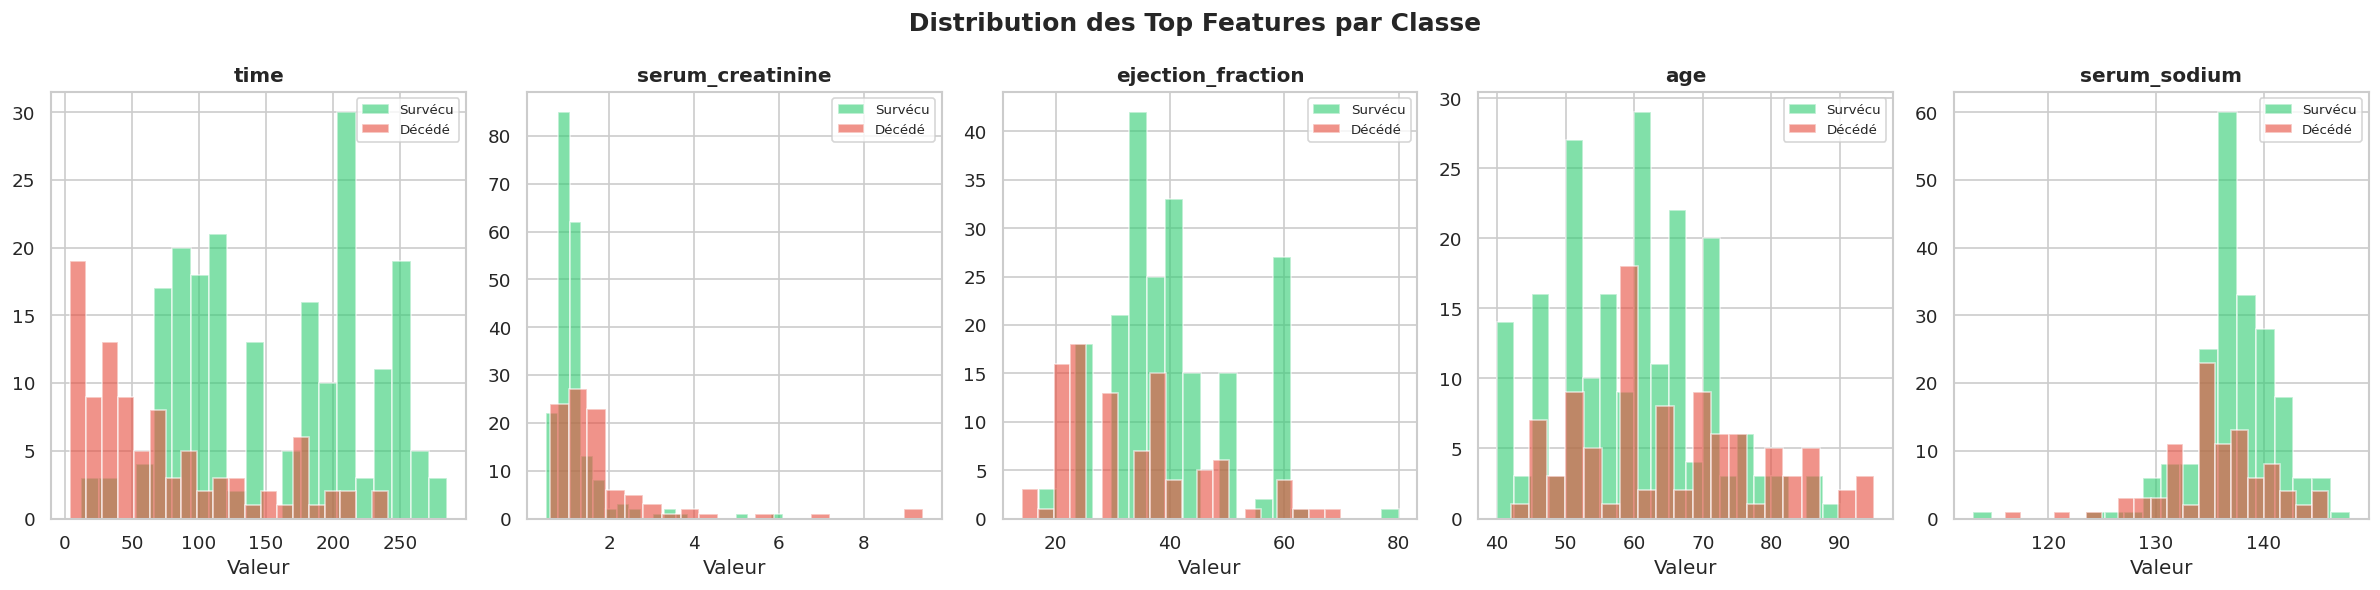

In [26]:
top_features = ['time', 'serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(top_features):
    for val, label, color in [(0, 'Survécu', '#2ecc71'), (1, 'Décédé', '#e74c3c')]:
        axes[i].hist(df[df['DEATH_EVENT'] == val][col],
                     bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valeur')

fig.suptitle(' Distribution des Top Features par Classe', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##  9. Résumé — Réponses aux Questions Critiques

| Question | Réponse |
|----------|--------|
| **Valeurs manquantes ?** |  Aucune — dataset complet |
 **Outliers ?** |  Présents dans `creatinine_phosphokinase` et `serum_creatinine` — conservés car données médicales réelles |
| **Déséquilibre des classes ?** |  Oui — 67.9% survivants vs 32.1% décédés → traité par **SMOTE** |
| **Corrélations fortes ?** |  `time` (-0.527), `ejection_fraction` (-0.269), `serum_creatinine` (+0.294) sont les features les plus importantes |

